### Importing libraries

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib
import warnings
warnings.filterwarnings("ignore")


Using matplotlib backend: inline


### Load data

In [29]:
df=pd.read_csv("dataset.csv")

### Basic data exploration

In [30]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   # ----------------------------------------  3183 non-null   str  
 1   Unnamed: 1                                  3183 non-null   str  
 2   Unnamed: 2                                  3183 non-null   str  
 3   Unnamed: 3                                  3183 non-null   str  
 4   Unnamed: 4                                  3183 non-null   str  
 5   Unnamed: 5                                  3183 non-null   str  
 6   Unnamed: 6                                  3183 non-null   str  
 7   Unnamed: 7                                  3183 non-null   str  
 8   Unnamed: 8                                  3183 non-null   str  
 9   Unnamed: 9                                  3183 non-null   str  
dtypes: str(10)
memory usage: 248.8 KB


### Data cleaning

In [32]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns=["session group","DateHour","Users","Sessions","Engaged sessions","Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]

In [33]:
df.head()

,session group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   session group                        3182 non-null   str  
 1   DateHour                             3182 non-null   str  
 2   Users                                3182 non-null   str  
 3   Sessions                             3182 non-null   str  
 4   Engaged sessions                     3182 non-null   str  
 5   Average engagement time per session  3182 non-null   str  
 6   Engaged sessions per user            3182 non-null   str  
 7   Events per session                   3182 non-null   str  
 8   Engagement rate                      3182 non-null   str  
 9   Event count                          3182 non-null   str  
dtypes: str(10)
memory usage: 248.7 KB


In [35]:
df["DateHour"]=pd.to_datetime(df["DateHour"],format="%Y%m%d%H",errors="coerce")
numeric_cols=df.columns.drop(["session group","DateHour"])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors="coerce")
df["Hour"]=df["DateHour"].dt.hour

In [36]:
df.head()

,session group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [37]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


### Q-1 What patterns or trends can you observe in website sessions and users over time?

In [38]:
sns.set(style="whitegrid")

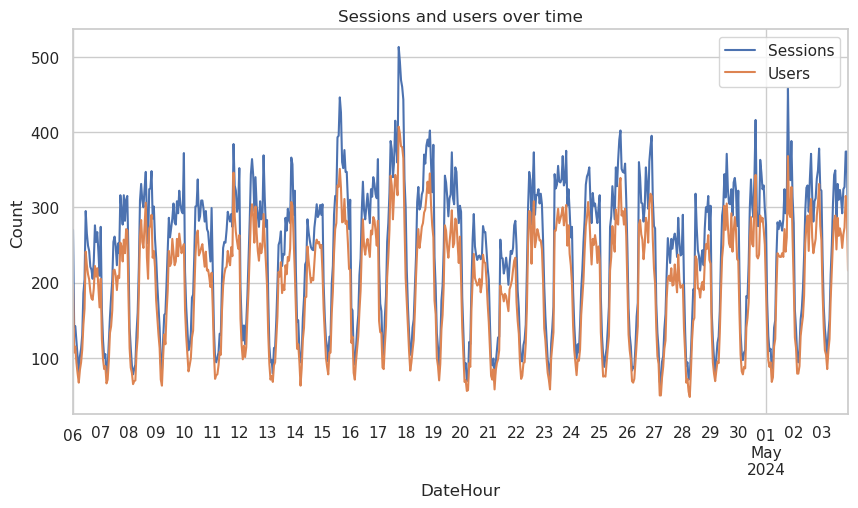

In [39]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and users over time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.show()

### Q-2 Which marketing channel brought the highest number of users to the website,and how we can use this insight to improve traffic from other sources?

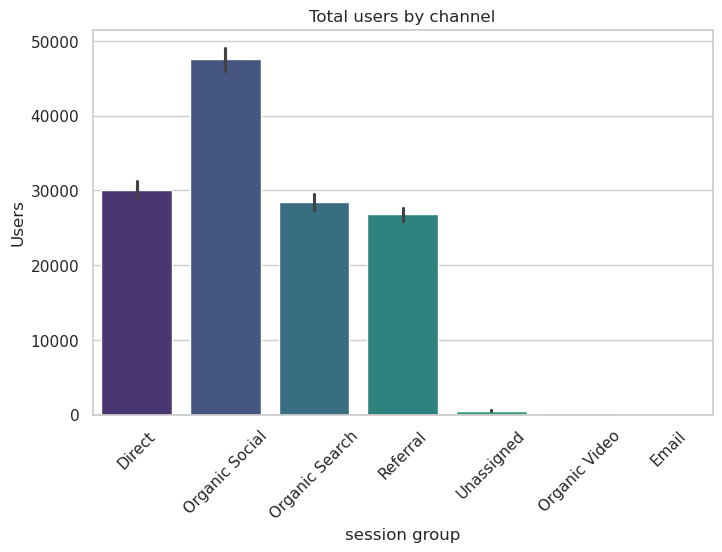

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="session group",y="Users",estimator=np.sum,palette="viridis")
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

In [41]:
df.head(3)

,session group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23


In [42]:
### Q-3 which channel has the highest average engagement time, and what does that tell us about user behavior and content effectiveness?

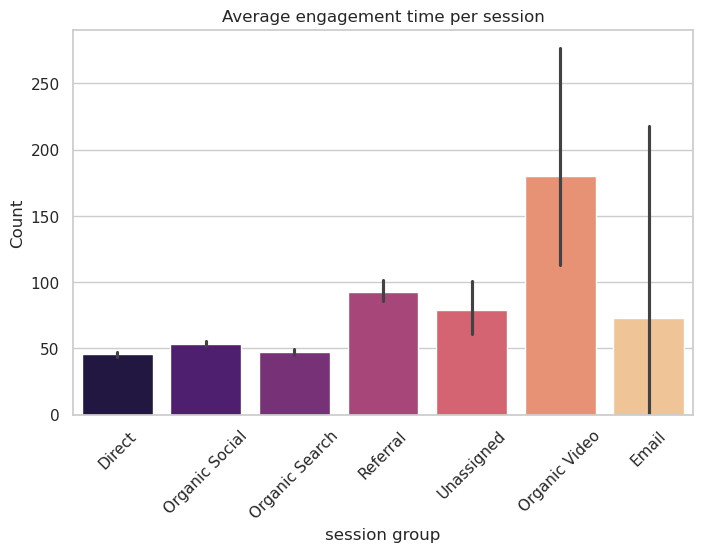

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="session group",y="Average engagement time per session",estimator=np.mean,palette="magma")
plt.title("Average engagement time per session")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

### Q-4 How does engagement rate vary across different traffic channels?

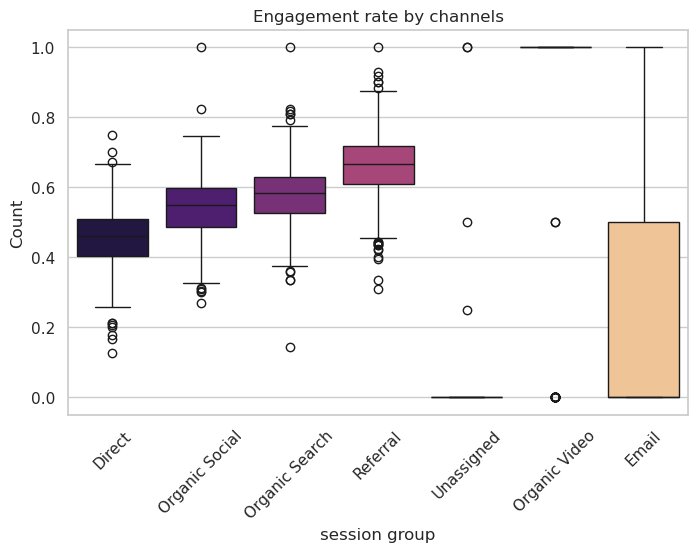

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="session group",y="Engagement rate",palette="magma")
plt.title("Engagement rate by channels")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

In [45]:
df.head(3)

,session group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23


### Q-5 Which channels are driving more engaged sessions compared to non-engaged ones, and what stratagies can improve engagement in underperforming channels?

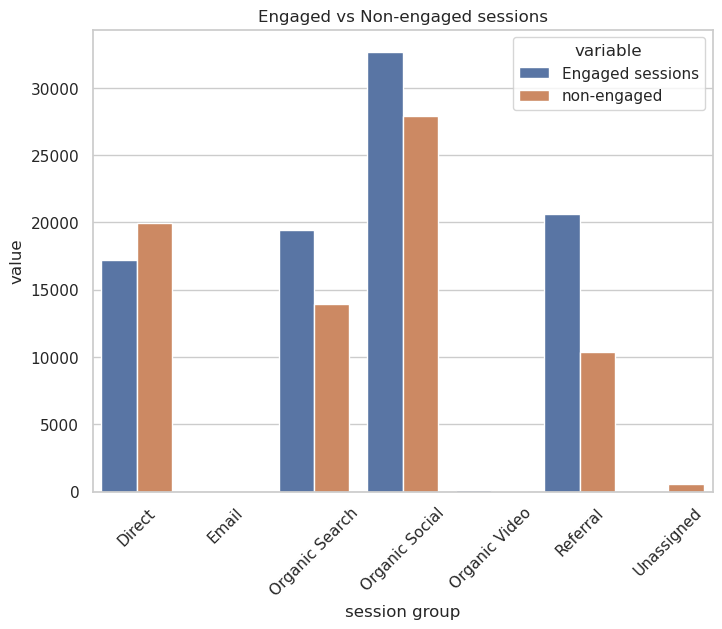

In [46]:
session_df=df.groupby("session group")[["Sessions","Engaged sessions"]].sum().reset_index()
session_df["non-engaged"]=session_df["Sessions"]-session_df["Engaged sessions"]
session_df_melted=session_df.melt(id_vars="session group",value_vars=["Engaged sessions","non-engaged"])

plt.figure(figsize=(8,6))
sns.barplot(data=session_df_melted,x="session group",y="value",hue="variable")
plt.title("Engaged vs Non-engaged sessions")
plt.xticks(rotation=45)
plt.show()

### Q-6 At what hours of the day does each channel drive the most traffic?

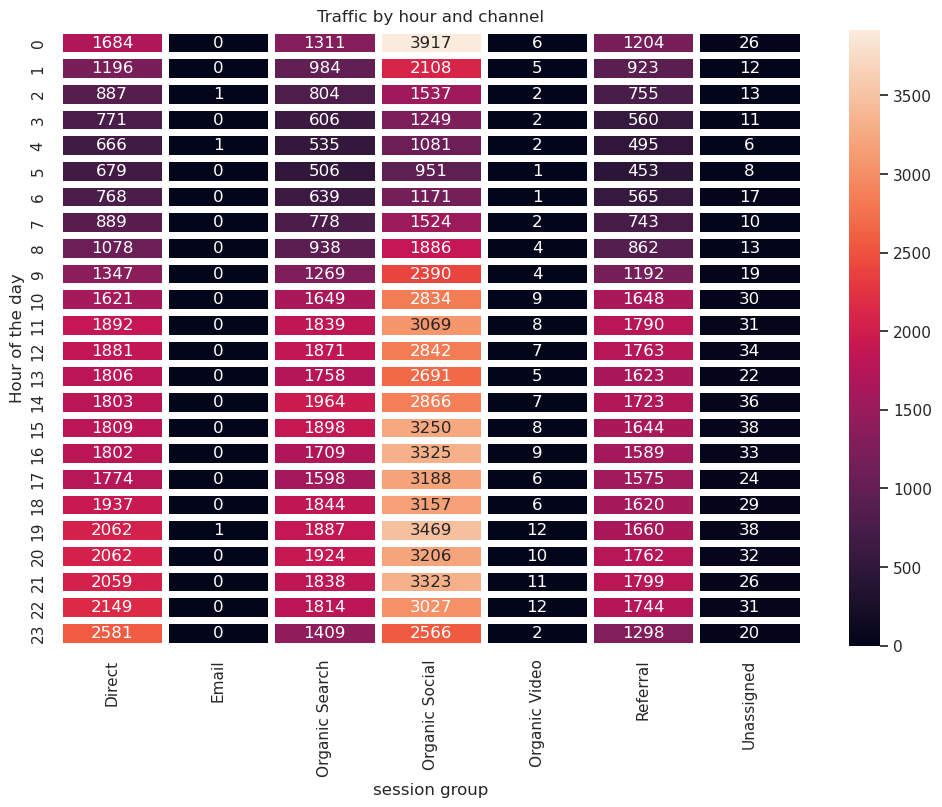

In [47]:
heatmap=df.groupby(["Hour","session group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(heatmap,linewidth=5,annot=True,fmt=".0f")
plt.title("Traffic by hour and channel")
plt.xlabel("session group")
plt.ylabel("Hour of the day")
plt.show()

In [48]:
df.head()

,session group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [49]:
### Q-7 Is there any correlation between high traffic (sessions) and high engagement rate over time?

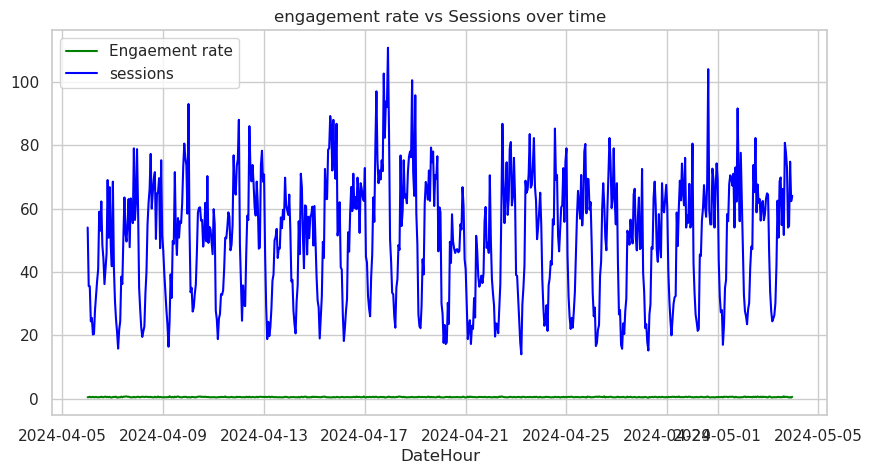

In [50]:
plt.figure(figsize=(10,5))
df_plot=df.groupby("DateHour")[["Engagement rate","Sessions"]].mean().reset_index()

plt.plot(df_plot["DateHour"],df_plot["Engagement rate"],label="Engaement rate",color="green")
plt.plot(df_plot["DateHour"],df_plot["Sessions"],label="sessions",color="blue")
plt.title("engagement rate vs Sessions over time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()